# Preprocesamiento de datos

## Librerías

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Rutas

In [ ]:
# CARGAR LOS DATOS
raw_path = os.path.join("..", "..", "data", "raw", "cancer_dataset.csv")
df = pd.read_csv(raw_path)
print("Dimensiones iniciales:", df.shape)
display(df.head())

Dimensiones iniciales: (160000, 23)


,Country,Age_Group,Cancer_Type,Risk_Factors,Incidence,Mortality,Prevalence,Urban_Population,Health_Expenditure_%GDP,Tobacco_Use_%,Alcohol_Consumption_Liters,Physical_Activity_%,Obesity_%,Air_Quality_Index,UV_Radiation,Family_History_%,Genetic_Mutation_%,Treatment_Coverage_%,GDP_per_Capita,Life_Expectancy,Health_Infrastructure_Index,Education_Index,Population_Density
0,Turkey,15-24,Lung,Obesity,44,457,955,32.906758,11.834005,12.578421,1.445909,33.197197,33.944196,96,2.877395,44.300862,6.924822,97.210912,29779,82.366306,2.324139,0.875452,736.609006
1,Canada,0-14,Prostate,Genetic,643,278,150,40.207750,6.412955,25.120870,4.903533,41.992279,14.641975,69,9.851073,17.727832,7.480867,98.658890,27570,56.791854,2.875398,0.730587,827.101915
2,China,15-24,Breast,Pollution,565,161,1428,62.225708,7.066045,33.662102,5.707092,56.051626,29.286155,10,3.156956,45.250388,17.109909,80.144866,50479,62.069261,1.502259,0.757807,139.180394
3,India,15-24,Leukemia,Inactivity,509,117,1996,84.119599,12.102488,29.599358,9.894173,53.946642,33.498229,179,6.364374,18.079635,5.280028,84.765434,67829,60.673865,8.945143,0.805388,776.916329
4,Nigeria,15-24,Prostate,Pollution,288,170,383,37.403640,14.487316,15.348235,4.309904,52.548490,31.037963,151,9.038135,20.292538,7.763366,81.781825,77986,66.400764,7.332599,0.748743,494.974242


## Análisis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      160000 non-null  object 
 1   Age_Group                    160000 non-null  object 
 2   Cancer_Type                  160000 non-null  object 
 3   Risk_Factors                 160000 non-null  object 
 4   Incidence                    160000 non-null  int64  
 5   Mortality                    160000 non-null  int64  
 6   Prevalence                   160000 non-null  int64  
 7   Urban_Population             160000 non-null  float64
 8   Health_Expenditure_%GDP      160000 non-null  float64
 9   Tobacco_Use_%                160000 non-null  float64
 10  Alcohol_Consumption_Liters   160000 non-null  float64
 11  Physical_Activity_%          160000 non-null  float64
 12  Obesity_%                    160000 non-null  float64
 13 

In [4]:
df.shape

(160000, 23)

## Análisis estadístico

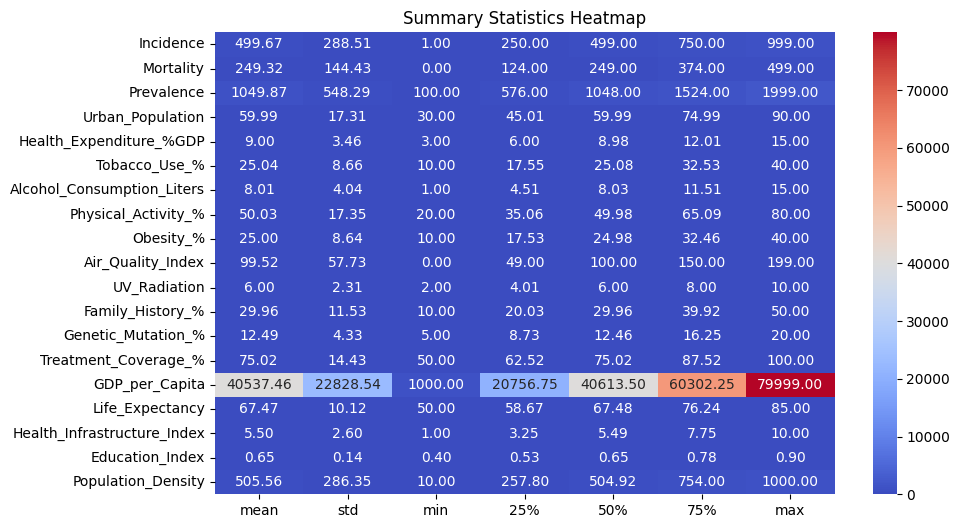

In [5]:
# Hacemos describe de todas las columnas numéricas

desc = df.describe().T
plt.figure(figsize=(10, 6))
sns.heatmap(desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']], annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Summary Statistics Heatmap')
plt.show()

In [6]:
# Buscamos valores nulos

df.isnull().sum()


Country                        0
Age_Group                      0
Cancer_Type                    0
Risk_Factors                   0
Incidence                      0
Mortality                      0
Prevalence                     0
Urban_Population               0
Health_Expenditure_%GDP        0
Tobacco_Use_%                  0
Alcohol_Consumption_Liters     0
Physical_Activity_%            0
Obesity_%                      0
Air_Quality_Index              0
UV_Radiation                   0
Family_History_%               0
Genetic_Mutation_%             0
Treatment_Coverage_%           0
GDP_per_Capita                 0
Life_Expectancy                0
Health_Infrastructure_Index    0
Education_Index                0
Population_Density             0
dtype: int64

No hay valores nulos en ninguna variable.

## Matriz de correlación

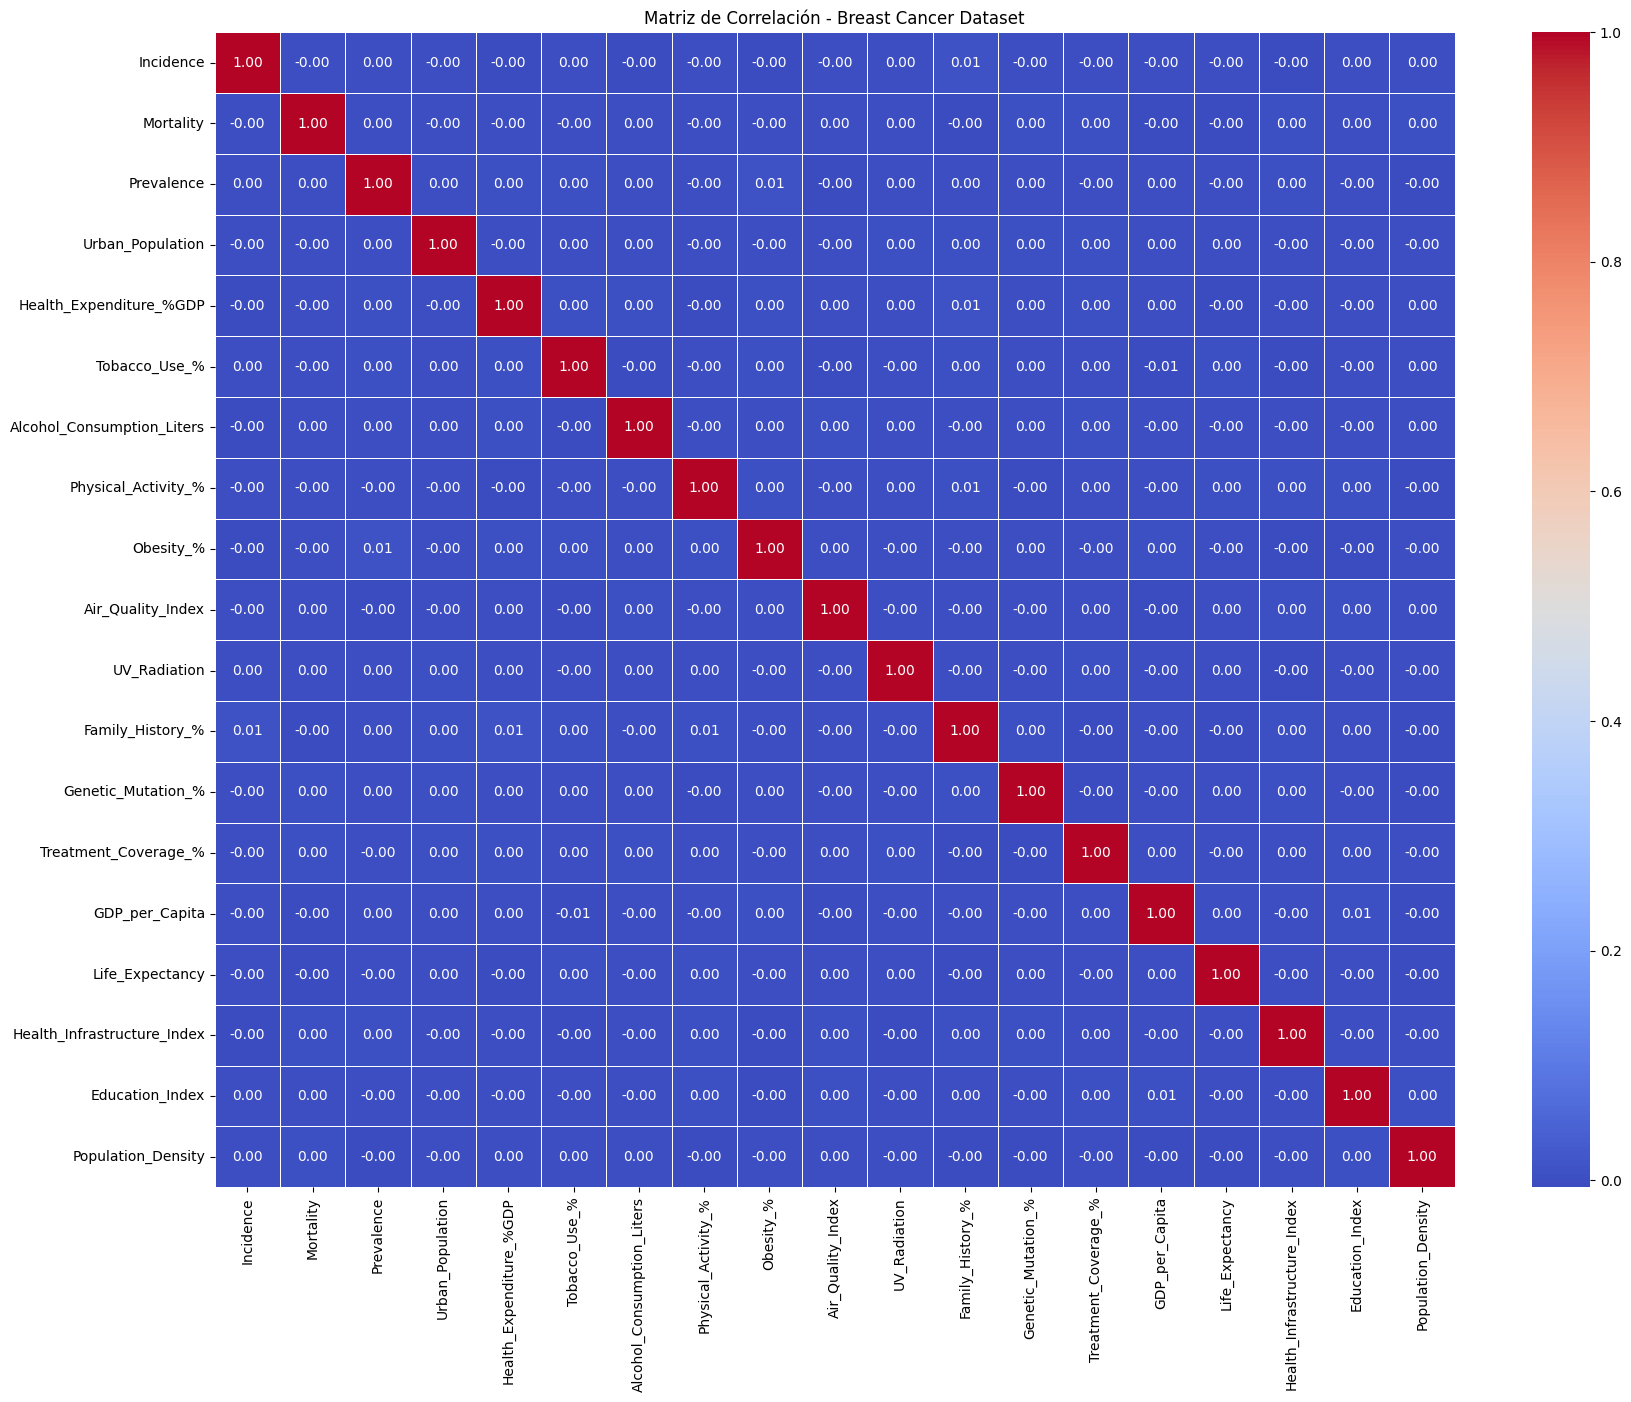

In [7]:
# 1. Calculamos la matriz de correlación
# Nota: Solo funciona con columnas numéricas, así que filtramos primero
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# 2. Configuramos el tamaño de la figura
plt.figure(figsize=(20, 15))

# 3. Dibujamos el heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # Muestra los números dentro de los cuadros
            fmt=".2f",        # Dos decimales
            cmap='coolwarm',  # Color azul (frío/negativo) a rojo (caliente/positivo)
            linewidths=0.5)

plt.title("Matriz de Correlación - Breast Cancer Dataset")
plt.show()

## Eliminamos outliers

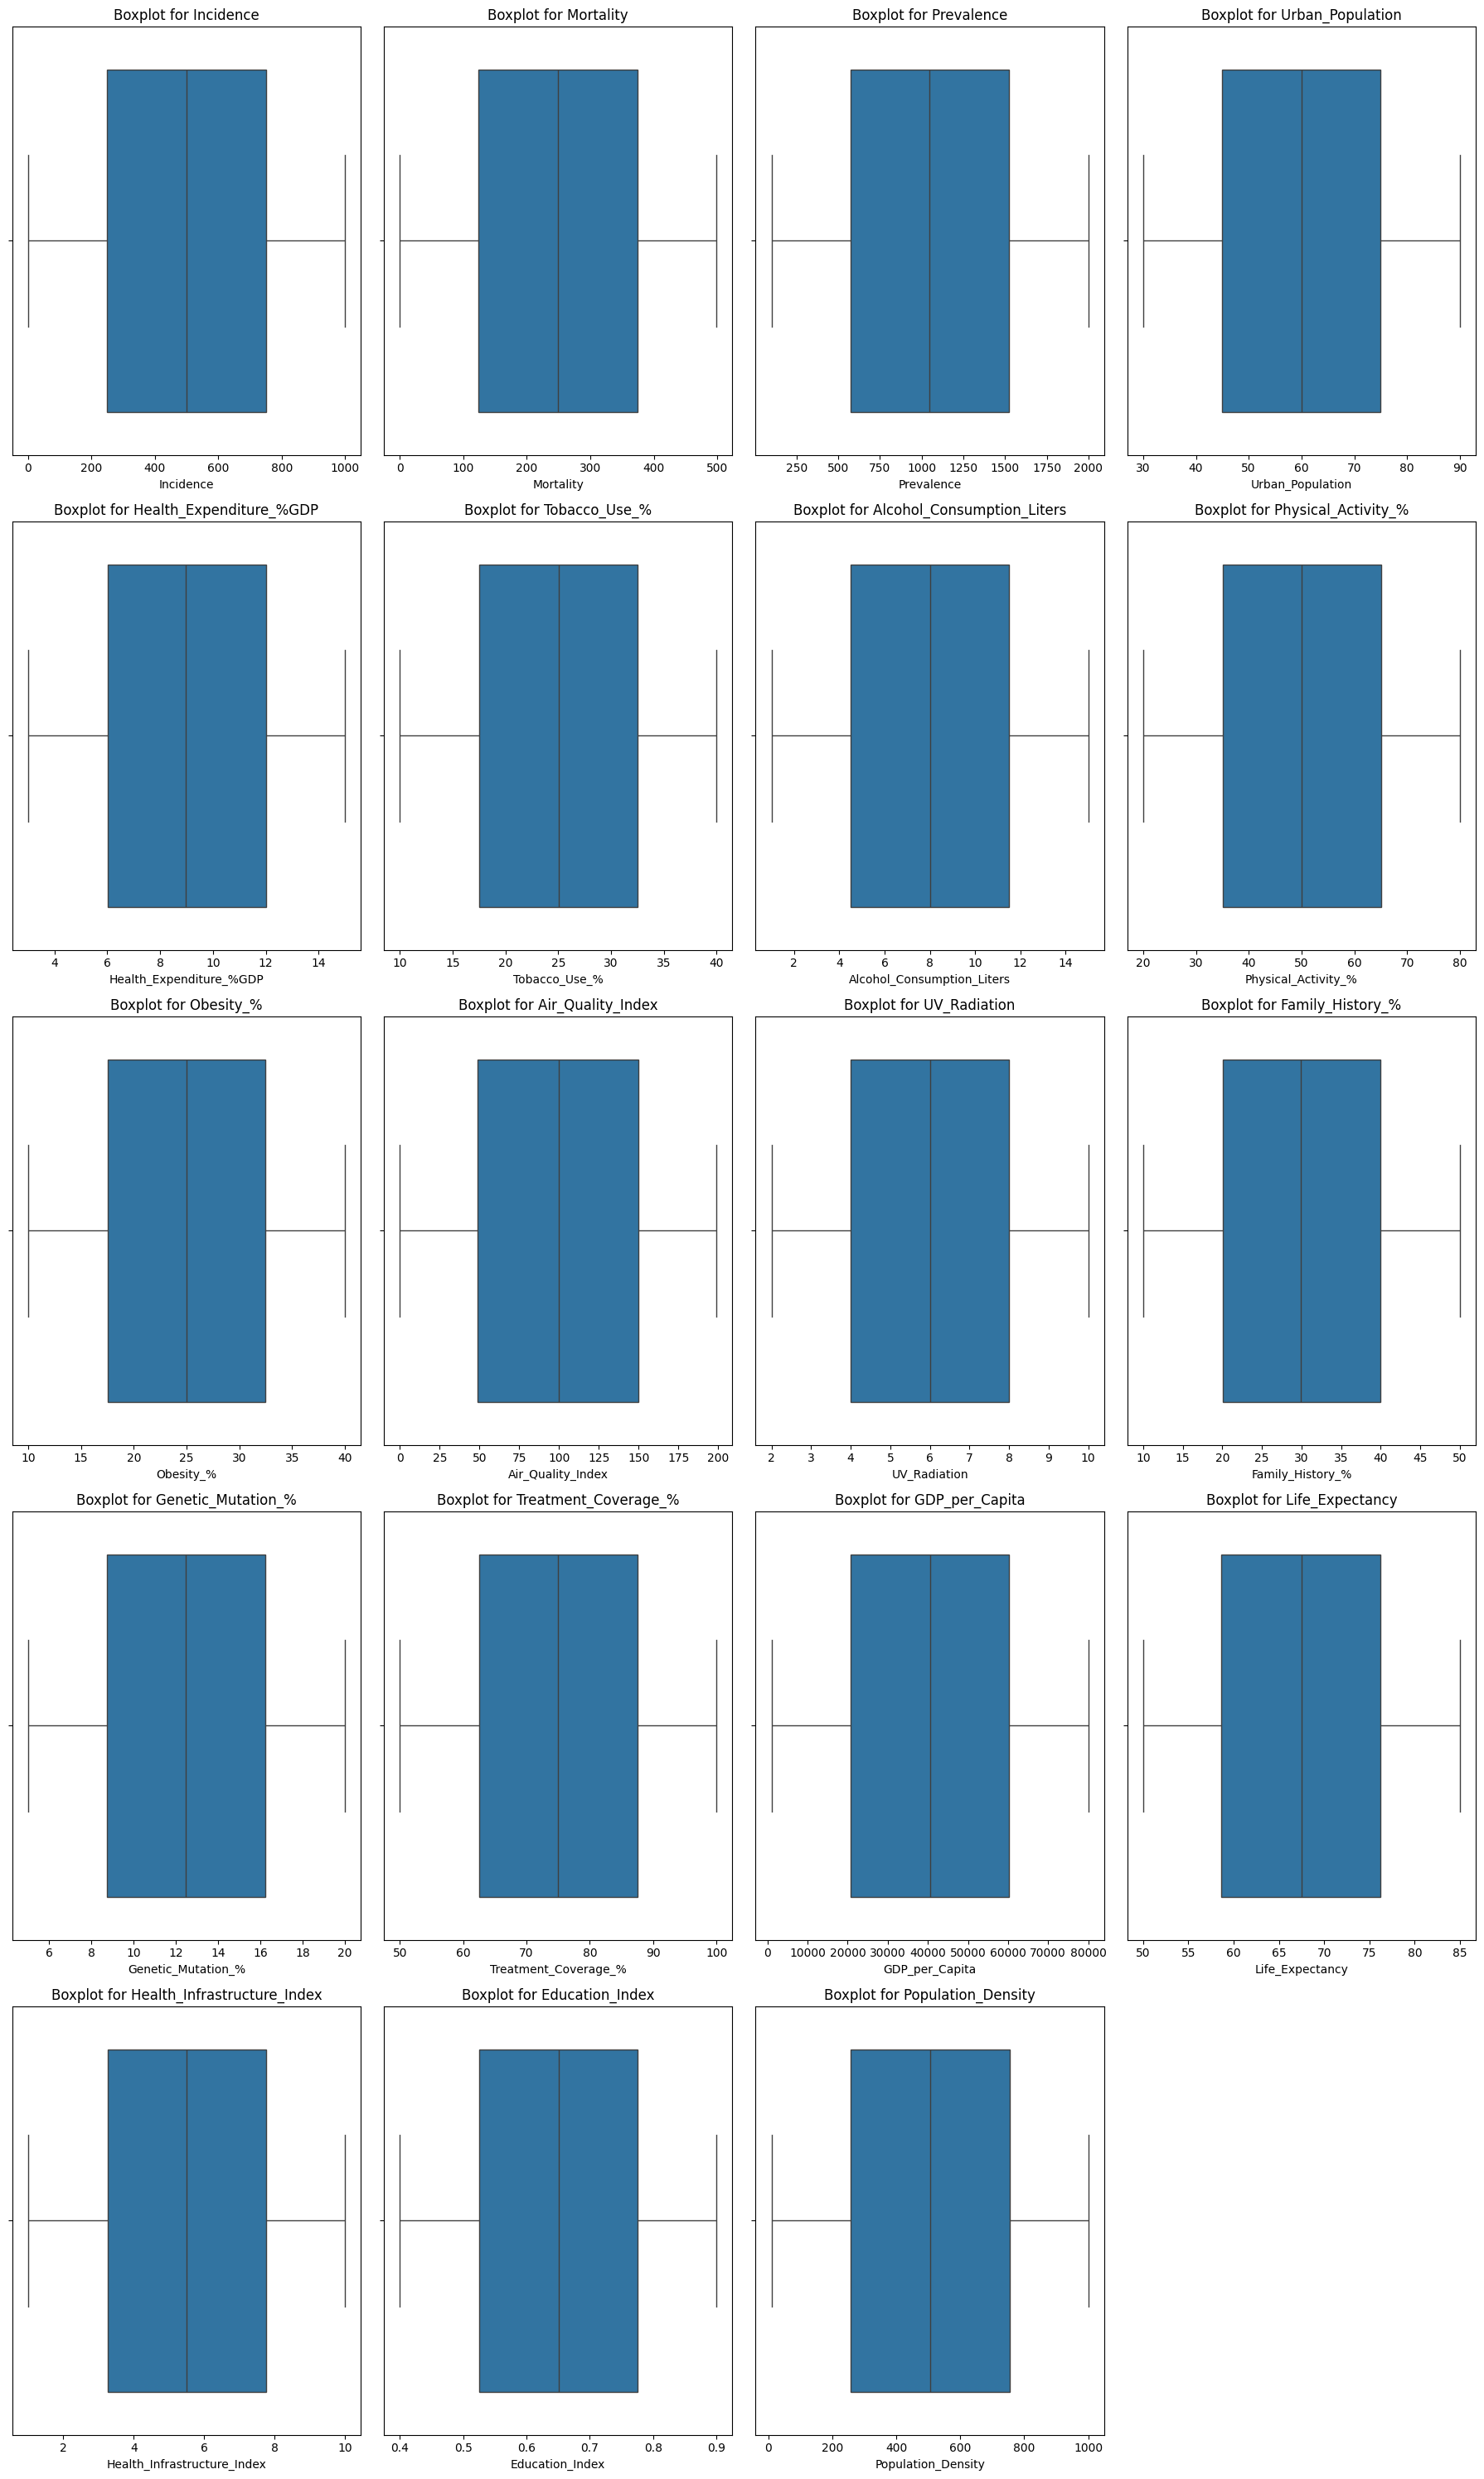

In [8]:
# Vamos a crear una función que elimine outliers y se lo aplicamos a todas las columnas numéricas, para quedarnos solo con datos típicos. Después
# representamos unos gráficos boxplot de cómo quedan las variables.

def remove_outliers(df):
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
    num_columns = len(numeric_columns)
    num_per_row = 4 
    num_rows = -(-num_columns // num_per_row)  

    fig, axes = plt.subplots(num_rows, num_per_row, figsize=(18, 6 * num_rows))
    axes = axes.flatten()
    
    for i, column in enumerate(numeric_columns):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        
        sns.boxplot(x=df[column], ax=axes[i])
        axes[i].set_title(f'Boxplot for {column}')
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return df

df = remove_outliers(df)

In [9]:
df.shape

(160000, 23)

## Distribución de Life Expectancy

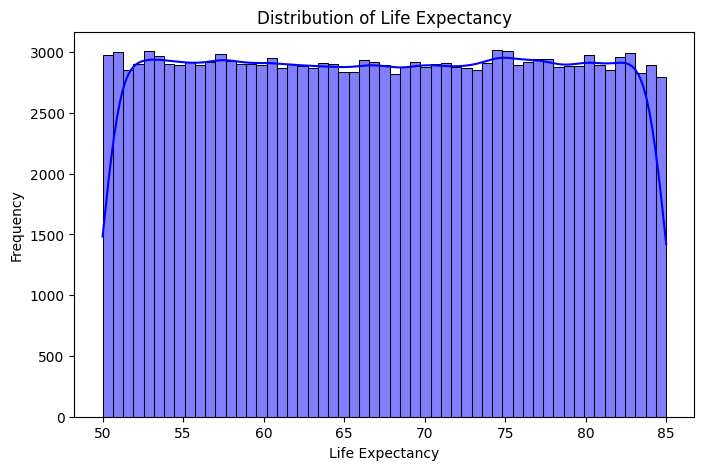

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Life_Expectancy'], kde=True, color='blue')
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.show()

## Frecuencia de cada tipo de cáncer

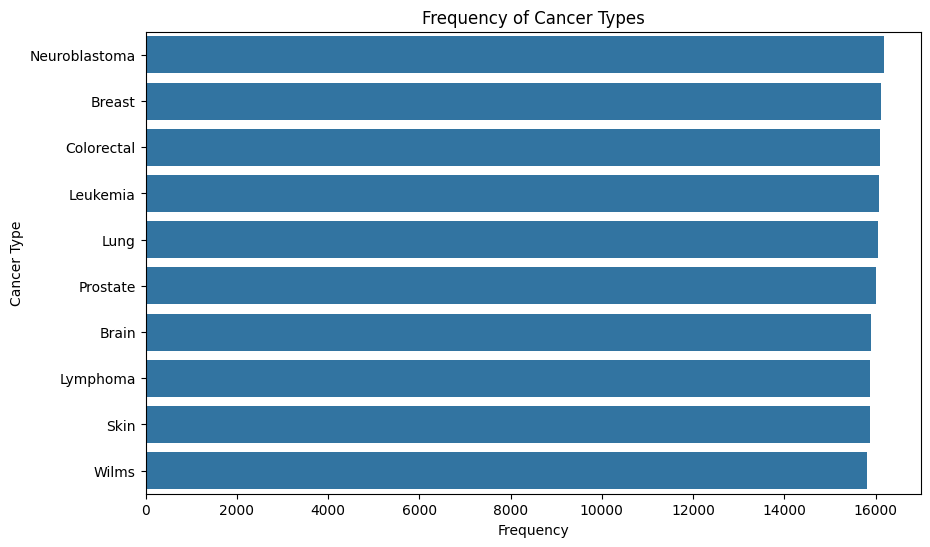

In [11]:
#colors = ['#1e2a38', '#3e5968', '#00b8b8', '#006f4f', '#2b3d4f', '#4f6f7e', '#00a5a5', '#005b46', '#284f63', '#5f797b']

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Cancer_Type', order=df['Cancer_Type'].value_counts().index)
plt.title('Frequency of Cancer Types')
plt.xlabel('Frequency')
plt.ylabel('Cancer Type')
plt.show()

## Health Expenditure vs Life Expectancy

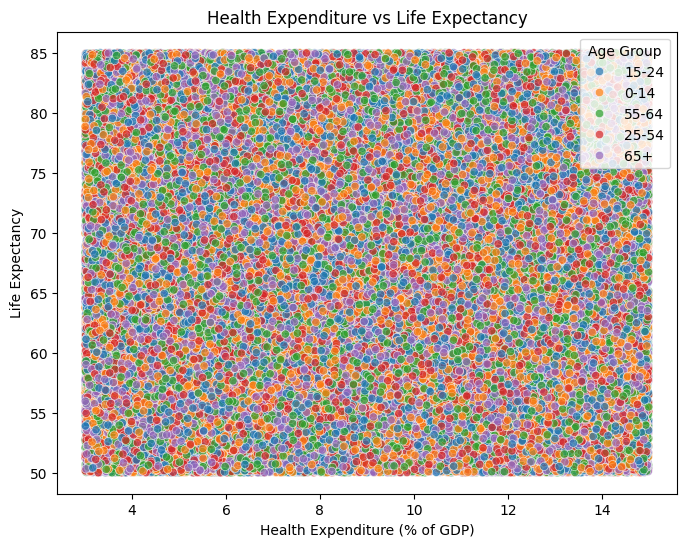

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Health_Expenditure_%GDP', y='Life_Expectancy', hue='Age_Group', alpha=0.7)
plt.title('Health Expenditure vs Life Expectancy')
plt.xlabel('Health Expenditure (% of GDP)')
plt.ylabel('Life Expectancy')
plt.legend(title='Age Group')
plt.show()

## Incidencia por tipo de cáncer

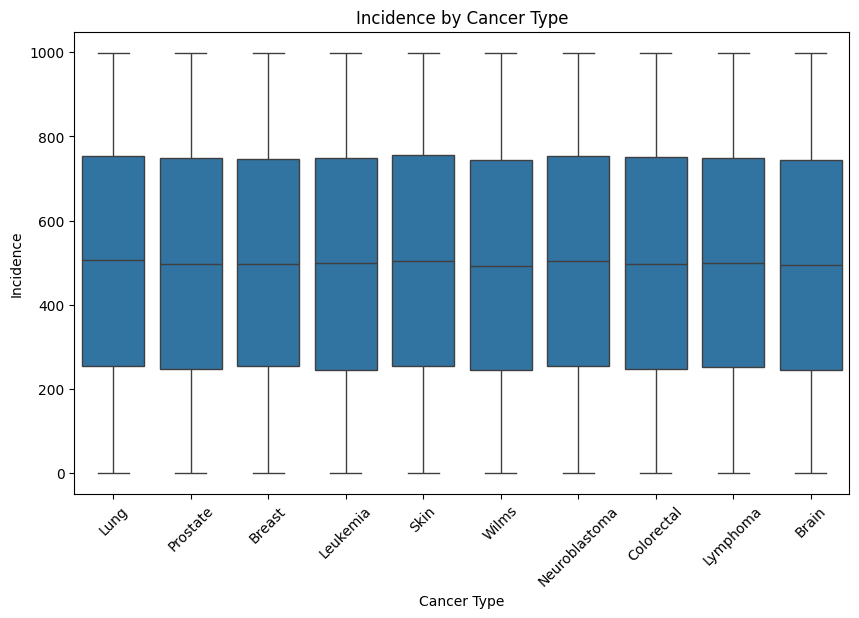

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cancer_Type', y='Incidence')
plt.title('Incidence by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Incidence')
plt.xticks(rotation=45)
plt.show()

## Análisis dos a dos de Life Expectancy con Health_Expenditure_%GDP, Incidence y Mortality

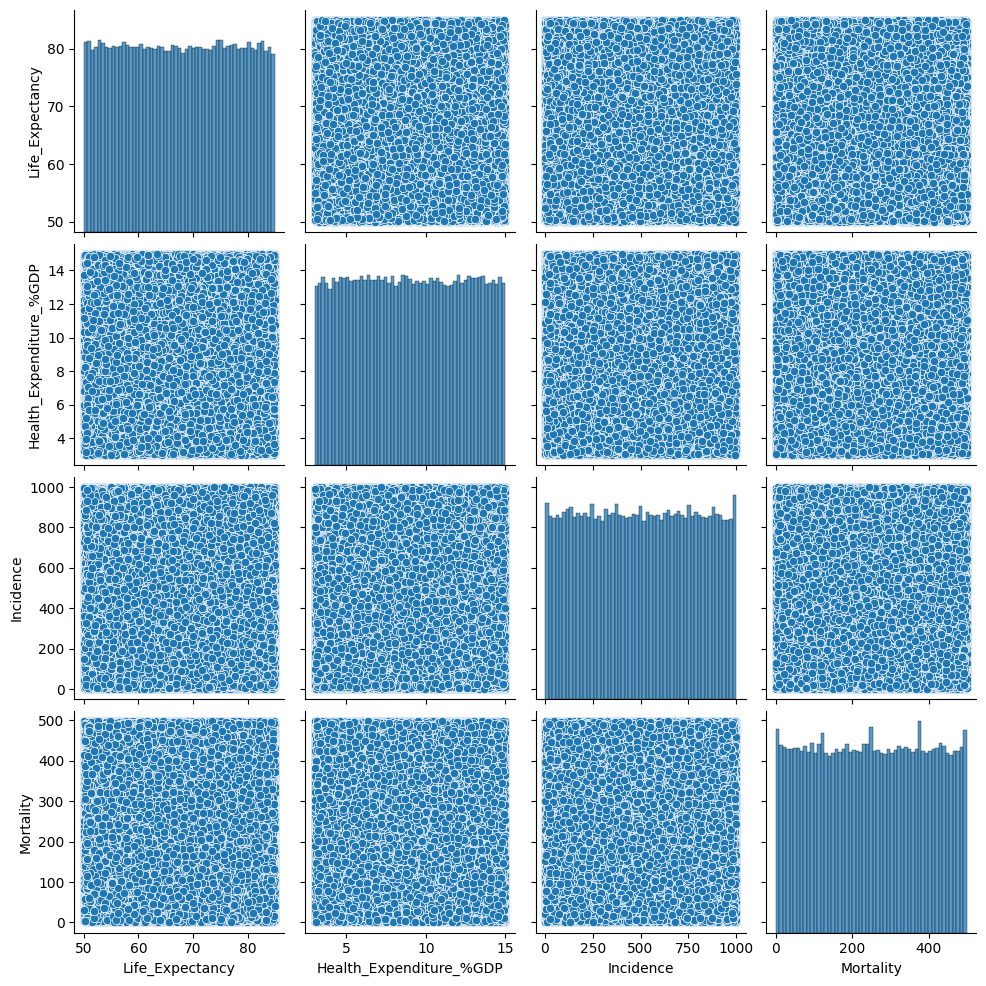

In [14]:
numeric_cols = ['Life_Expectancy', 'Health_Expenditure_%GDP', 'Incidence', 'Mortality']
sns.pairplot(df[numeric_cols])
plt.show()

## Uso de tabaco vs mortalidad

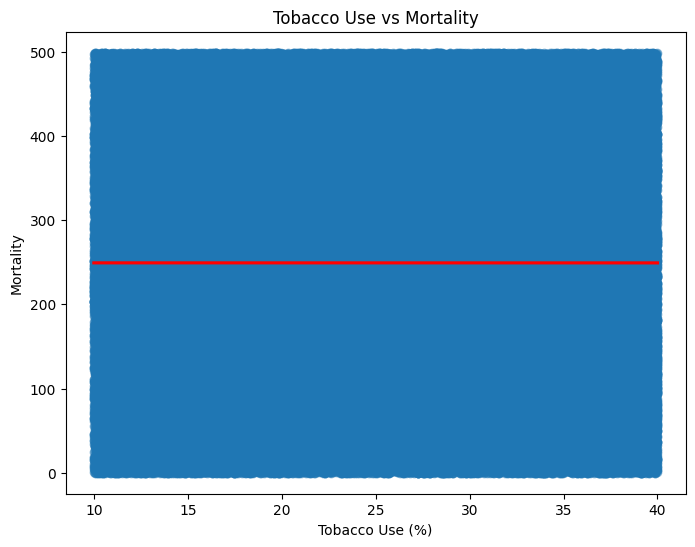

In [15]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Tobacco_Use_%', y='Mortality', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Tobacco Use vs Mortality')
plt.xlabel('Tobacco Use (%)')
plt.ylabel('Mortality')
plt.show()

## Conclusiones

No hemos tenido que sustituir valores nulos, porque no había, hemos eliminado posibles outliers y los datos parecen ser bastante homogéneos. Sin embargo, todos los datos de todas las variables parecen estar distribuídas uniformemente, esto puede causar problemas al modelo para aprender, porque parece que ninguna variable influye en ninguna otra. Hemos visto en la matriz de correlación que ninguna variable está correlacionada con otra. Las distribuciones son bastante parecidas una con otra, los tipos de cánceres tienen incidencias similares, el life expectancy es igual de frecuente con 50 que con 80. Veámos cómo se comporta el modelo a estos datos tan homogéneos.